# 📘 Lecture 11: Gaussian Conditionals, Schur's Complement, Bayes' Rule for Gaussians, & Sensor Fusion
**Course**: Probabilistic Machine Learning by Aayush  
**Video Reference**: [Lecture 11 - YouTube](https://youtu.be/ViVBWYyL_8c?si=-T-GNc7Sjd1yjpXh)

---
### 📌 Executive Overview & Core Objectives
In this lecture, we dive into the advanced linear-algebraic and Bayesian mechanics of Multivariate Gaussians:
1. **Gaussian Conditionals & Schur's Complement**: Deriving closed-form conditional distributions $\mathbf{y}_1 \mid \mathbf{y}_2 \sim \mathcal{N}(\boldsymbol{\mu}_{1|2}, \boldsymbol{\Sigma}_{1|2})$ via block-matrix inversion $\mathbf{M}^{-1}$ and Schur's complement $\boldsymbol{\Sigma}_{1|2} = \boldsymbol{\Sigma}_{11} - \boldsymbol{\Sigma}_{12} \boldsymbol{\Sigma}_{22}^{-1} \boldsymbol{\Sigma}_{21}$.
2. **Bivariate Conditioning**: Proving conditional variance reduction $\sigma_{1|2}^2 = \sigma_1^2 (1 - \rho^2) \le \sigma_1^2$ (slicing vs. projecting 2D Gaussian density).
3. **Missing Data Imputation**: Inferring hidden dimensions $\mathbf{y}_h$ from observed dimensions $\mathbf{y}_v$ by computing posterior mean $\boldsymbol{\mu}_{h|v}$ to minimize expected squared error risk.
4. **Linear Gaussian Systems & Bayes' Rule for Gaussians**: Proving conjugate closure (Gaussian prior + Gaussian likelihood = Gaussian posterior), deriving posterior precision $\boldsymbol{\Sigma}_{z|y}^{-1} = \boldsymbol{\Sigma}_z^{-1} + \mathbf{W}^\top \boldsymbol{\Sigma}_y^{-1} \mathbf{W}$.
5. **Inferring Unknown Scalar & Shrinkage Effect**: Demonstrating how posterior mean $\mu_N$ is a convex combination of prior mean $\mu_0$ and MLE sample mean $\bar{y}$, and how precision accumulates $\frac{1}{\tau_N^2} = \frac{1}{\tau_0^2} + \frac{N}{\sigma_y^2}$.
6. **Sensor Fusion & 2D Aircraft Tracking**: Implementing multi-sensor fusion combining complementary radar sensors ($S_1, S_2$) to sequentially track an aircraft's position.

---


## 0️⃣ Environment Setup & Imports
We start by importing scientific computation, statistics, linear algebra, and plotting libraries.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for 100% reproducible results
np.random.seed(42)
print("✅ Libraries imported successfully! NumPy Version:", np.__version__)


✅ Libraries imported successfully! NumPy Version: 2.1.3


## 1️⃣ Marginals, Conditionals & Schur's Complement

### 1.1 Partitioned Multivariate Gaussian
Let $\mathbf{Y} = [\mathbf{y}_1^\top, \mathbf{y}_2^\top]^\top \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ be partitioned as:
$$\boldsymbol{\mu} = \begin{bmatrix} \boldsymbol{\mu}_1 \\ \boldsymbol{\mu}_2 \end{bmatrix}, \quad \boldsymbol{\Sigma} = \begin{bmatrix} \boldsymbol{\Sigma}_{11} & \boldsymbol{\Sigma}_{12} \\ \boldsymbol{\Sigma}_{21} & \boldsymbol{\Sigma}_{22} \end{bmatrix}, \quad \boldsymbol{\Lambda} = \boldsymbol{\Sigma}^{-1} = \begin{bmatrix} \boldsymbol{\Lambda}_{11} & \boldsymbol{\Lambda}_{12} \\ \boldsymbol{\Lambda}_{21} & \boldsymbol{\Lambda}_{22} \end{bmatrix}$$

#### Marginals:
$$\mathbf{y}_1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_{11}), \quad \mathbf{y}_2 \sim \mathcal{N}(\boldsymbol{\mu}_2, \boldsymbol{\Sigma}_{22})$$

#### Conditionals $P(\mathbf{y}_1 \mid \mathbf{y}_2) = \mathcal{N}(\boldsymbol{\mu}_{1|2}, \boldsymbol{\Sigma}_{1|2})$ via Schur's Complement:
- **Posterior Mean**:
  $$\boldsymbol{\mu}_{1|2} = \boldsymbol{\mu}_1 + \boldsymbol{\Sigma}_{12} \boldsymbol{\Sigma}_{22}^{-1} (\mathbf{y}_2 - \boldsymbol{\mu}_2) = \boldsymbol{\mu}_1 - \boldsymbol{\Lambda}_{11}^{-1} \boldsymbol{\Lambda}_{12} (\mathbf{y}_2 - \boldsymbol{\mu}_2)$$
- **Posterior Covariance (Schur's Complement)**:
  $$\boldsymbol{\Sigma}_{1|2} = \boldsymbol{\Sigma}_{11} - \boldsymbol{\Sigma}_{12} \boldsymbol{\Sigma}_{22}^{-1} \boldsymbol{\Sigma}_{21} = \boldsymbol{\Lambda}_{11}^{-1}$$

### 1.2 Bivariate Gaussian Conditioning Case Study
For 2D Gaussian with correlation $\rho$:
$$\mu_{1|2} = \mu_1 + \rho \frac{\sigma_1}{\sigma_2} (y_2 - \mu_2), \quad \sigma_{1|2}^2 = \sigma_1^2 (1 - \rho^2)$$
Observing $y_2$ reduces uncertainty in $y_1$ by factor $(1 - \rho^2) \le 1$!

Bivariate conditional moments
 Marginal y1 : Mean = 0.00, Std = 2.00
 Observed y2: 1.50
Conditional y1|y2=1.5: Mean = 1.60, Std = 1.20


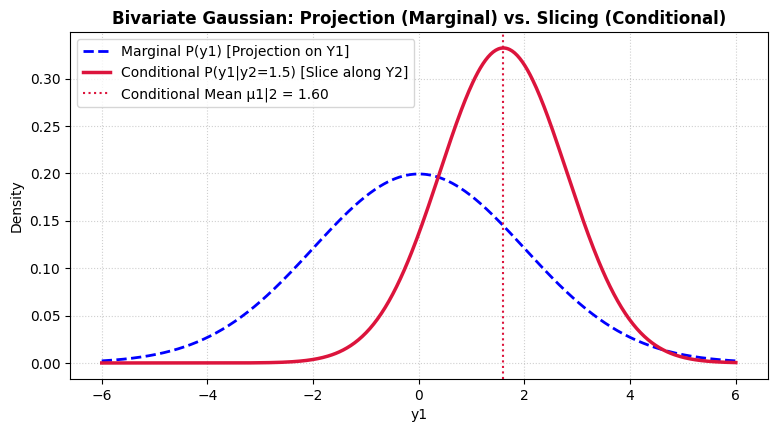

In [3]:
#Start code here...
#Code verification of Bivariate Gaussian conditioning and slice vs projection
mu1, mu2 = 0.0, 0.0
sigma1, sigma2 = 2.0, 1.5
rho = 0.8 #high correlation

Sigma_biv = np.array([
    [sigma1**2, rho * sigma1 * sigma2],
    [rho * sigma1 * sigma2, sigma2**2]
])
#our observed value y2 = 1.5
y2_obs = 1.5

#Analytical conditional moments
mu1_given_y2 = mu1 + rho * (sigma1 / sigma2) * (y2_obs - mu2)
var1_given_y2 = (sigma1**2) * (1 - rho**2)
std1_given_y2 = np.sqrt(var1_given_y2)

print("Bivariate conditional moments")
print(f" Marginal y1 : Mean = {mu1:.2f}, Std = {sigma1:.2f}")
print(f" Observed y2: {y2_obs:.2f}")
print(f"Conditional y1|y2={y2_obs}: Mean = {mu1_given_y2:.2f}, Std = {std1_given_y2:.2f}")

grid_y1 = np.linspace(-6,6,500)
marginal_pdf_y1 = stats.norm.pdf(grid_y1, mu1, sigma1)
conditional_pdf_y1 = stats.norm.pdf(grid_y1, mu1_given_y2, std1_given_y2)


#End code here...

plt.figure(figsize=(9, 4.5))
plt.plot(grid_y1, marginal_pdf_y1, color='blue', linewidth=2, linestyle='--', label='Marginal P(y1) [Projection on Y1]')
plt.plot(grid_y1, conditional_pdf_y1, color='crimson', linewidth=2.5, label=f'Conditional P(y1|y2={y2_obs}) [Slice along Y2]')
plt.axvline(mu1_given_y2, color='crimson', linestyle=':', label=f'Conditional Mean μ1|2 = {mu1_given_y2:.2f}')
plt.xlabel('y1')
plt.ylabel('Density')
plt.title('Bivariate Gaussian: Projection (Marginal) vs. Slicing (Conditional)', fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 2️⃣ Missing Value Imputation

### 2.1 Optimal Imputation under Expected Squared Error Risk
When an observation vector $\mathbf{Y}$ has missing/hidden dimensions $\mathbf{y}_h$ and visible dimensions $\mathbf{y}_v$:
$$\mathbf{y}_h \mid \mathbf{y}_v \sim \mathcal{N}(\boldsymbol{\mu}_{h|v}, \boldsymbol{\Sigma}_{h|v})$$
The optimal point estimate minimizing expected squared error risk is the **Posterior Mean**:
$$\hat{\mathbf{y}}_h = \mathbb{E}[\mathbf{y}_h \mid \mathbf{y}_v] = \boldsymbol{\mu}_h + \boldsymbol{\Sigma}_{hv} \boldsymbol{\Sigma}_{vv}^{-1} (\mathbf{y}_v - \boldsymbol{\mu}_v)$$


In [6]:
#Start code here...
#Missing value imputation in 4D Gaussian Vector:
D = 4
mu_4d = np.array([1.0, 2.0, -1.0, 0.5])
Sigma_4d = np.array([
    [2.0, 0.8, 0.5, 0.2],
    [0.8, 1.5, 0.4, 0.1],
    [0.5, 0.4, 1.8, 0.6],
    [0.2, 0.1, 0.6, 1.0]
])

#Supposing that dimensions 0 and 2 are visible, and dimensions 1 and 3 are missing(hidden)
vis_idx = [0,2]
hid_idx = [1,3]
y_vis = np.array([2.5, -0.2]) #observed data for dimension 0 and 2

mu_v = mu_4d[vis_idx]
mu_h = mu_4d[hid_idx]
Sigma_vv = Sigma_4d[np.ix_(vis_idx, vis_idx)]
Sigma_hh = Sigma_4d[np.ix_(hid_idx, hid_idx)]
Sigma_hv = Sigma_4d[np.ix_(hid_idx, vis_idx)]

#Computing the posterior imputation
mu_h_given_v = mu_h + Sigma_hv @ np.linalg.solve(Sigma_vv, y_vis - mu_v)
Sigma_h_given_v = Sigma_hh - Sigma_hv @ np.linalg.solve(Sigma_vv, Sigma_hv.T)
#End code here...

print("📊 Missing Data Imputation Results:")
print(f"   Visible Inputs (Dim 0, 2): {y_vis}")
print(f"   Optimal Imputed Values (Dim 1, 3): {mu_h_given_v.round(4)}")
print("   Imputation Uncertainty Covariance Σ_{h|v}:")
print(Sigma_h_given_v.round(4))


📊 Missing Data Imputation Results:
   Visible Inputs (Dim 0, 2): [ 2.5 -0.2]
   Optimal Imputed Values (Dim 1, 3): [2.6507 0.7896]
   Imputation Uncertainty Covariance Σ_{h|v}:
[[ 1.1561 -0.0457]
 [-0.0457  0.7994]]


## 3️⃣ Linear Gaussian Systems & Bayes' Rule for Gaussians

### 3.1 Formal Model
Let latent vector $\mathbf{z} \in \mathbb{R}^L$ and observation vector $\mathbf{y} \in \mathbb{R}^D$ be modeled as:
- **Latent Prior**: $\mathbf{z} \sim \mathcal{N}(\boldsymbol{\mu}_z, \boldsymbol{\Sigma}_z)$
- **Linear Noisy Likelihood**: $\mathbf{y} \mid \mathbf{z} \sim \mathcal{N}(\mathbf{W}\mathbf{z} + \mathbf{b}, \boldsymbol{\Sigma}_y)$

### 3.2 Conjugate Posterior Derivation
Because Gaussians are closed under Bayesian conditioning, the posterior $P(\mathbf{z} \mid \mathbf{y}) = \mathcal{N}(\boldsymbol{\mu}_{z|y}, \boldsymbol{\Sigma}_{z|y})$ is strictly Gaussian:
$$\boldsymbol{\Sigma}_{z|y}^{-1} = \boldsymbol{\Sigma}_z^{-1} + \mathbf{W}^\top \boldsymbol{\Sigma}_y^{-1} \mathbf{W}$$
$$\boldsymbol{\mu}_{z|y} = \boldsymbol{\Sigma}_{z|y} \left[ \mathbf{W}^\top \boldsymbol{\Sigma}_y^{-1} (\mathbf{y} - \mathbf{b}) + \boldsymbol{\Sigma}_z^{-1} \boldsymbol{\mu}_z \right]$$


In [8]:
#Start code here...
#Code verification of Bayes Rule for Linear Gaussian Systems
L, D = 2,2
mu_z = np.array([0.0, 0.0])
Sigma_z = np.eye(L) * 4.0 #broad prior
W_mat = np.array([[1.0, 0.5],
                  [0.0, 1.0]])
b_vec = np.array([0.5, -0.5])
Sigma_y = np.eye(D) * 0.5 #low observation noise

y_obs = np.array([2.0, 1.0])

#precision updates
Lambda_z = np.linalg.inv(Sigma_z)
Lambda_y = np.linalg.inv(Sigma_y)
Lambda_post = Lambda_z + W_mat.T @ Lambda_y @ W_mat
Sigma_post = np.linalg.inv(Lambda_post)
mu_post = Sigma_post @ (W_mat.T @ Lambda_y @ (y_obs - b_vec) + Lambda_z @ mu_z)

#End code here...
print("📊 Linear Gaussian Bayes' Rule Results:")
print(f"   Prior Mean μ_z:           {mu_z}")
print(f"   Observation Measurement y: {y_obs}")
print(f"   Posterior Latent Mean μ_{{z|y}}: {mu_post.round(4)}")
print("   Posterior Covariance Σ_{z|y}:")
print(Sigma_post.round(4))


📊 Linear Gaussian Bayes' Rule Results:
   Prior Mean μ_z:           [0. 0.]
   Observation Measurement y: [2. 1.]
   Posterior Latent Mean μ_{z|y}: [0.7229 1.3735]
   Posterior Covariance Σ_{z|y}:
[[ 0.5301 -0.1928]
 [-0.1928  0.4337]]


## 4️⃣ Inferring Unknown Scalar & Shrinkage Effect

### 4.1 Precision Accumulation & Convex Combination
For $N$ noisy measurements $y_1, \dots, y_N \sim \mathcal{N}(z, \sigma_y^2)$ with prior $z \sim \mathcal{N}(\mu_0, \tau_0^2)$:
1. **Precision Update**:
   $$\frac{1}{\tau_N^2} = \frac{1}{\tau_0^2} + \frac{N}{\sigma_y^2} \implies \text{Posterior Precision} = \text{Prior Precision} + N \times \text{Measurement Precision}$$
2. **Convex Combination Mean**:
   $$\mu_N = \frac{\frac{1}{\tau_0^2}}{\frac{1}{\tau_0^2} + \frac{N}{\sigma_y^2}} \mu_0 + \frac{\frac{N}{\sigma_y^2}}{\frac{1}{\tau_0^2} + \frac{N}{\sigma_y^2}} \bar{y}$$

### 4.2 Shrinkage Effect
- **Weak Prior (Low $\tau_0^{-2}$)**: $\mu_N \to \bar{y}$ (MLE sample mean dominates).
- **Strong Prior (High $\tau_0^{-2}$)**: $\mu_N \to \mu_0$ (Shrinkage toward prior mean).

📊 Measurement Sample Mean y_bar (MLE): 5.9180
   Weak Prior (τ0=10):   Posterior Mean μ_N = 5.8710 (Moves to y_bar)
   Strong Prior (τ0=0.5): Posterior Mean μ_N = 1.4090 (Shrinks toward μ0=0)


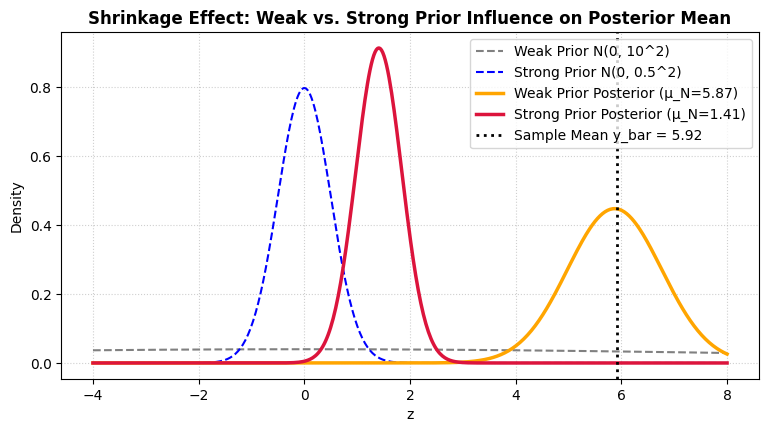

In [9]:
#Start code here...
# Simulation of Shrinkage Effect under Weak vs Strong Prior
true_z = 5.0
sigma_y = 2.0
N_obs = 5
y_measurements = np.random.normal(true_z, sigma_y, N_obs)
y_bar = np.mean(y_measurements)

mu_0 = 0.0 #prior centered at 0
tau_0_weak = 10.0 #weak prior (high variance)
tau_0_strong = 0.5 #strong prior

#weak prior updates
prec_weak = (1.0 / tau_0_weak**2) + (N_obs / sigma_y**2)
tau_N_weak = np.sqrt(1.0 / prec_weak)
mu_N_weak = ((mu_0 / tau_0_weak**2) + (N_obs * y_bar / sigma_y**2)) / prec_weak

#strong prior updates
prec_strong = (1.0 / tau_0_strong**2) + (N_obs / sigma_y**2)
tau_N_strong = np.sqrt(1.0 / prec_strong)
mu_N_strong = ((mu_0 / tau_0_strong**2) + (N_obs * y_bar / sigma_y**2)) / prec_strong

#End code here...

print(f"📊 Measurement Sample Mean y_bar (MLE): {y_bar:.4f}")
print(f"   Weak Prior (τ0=10):   Posterior Mean μ_N = {mu_N_weak:.4f} (Moves to y_bar)")
print(f"   Strong Prior (τ0=0.5): Posterior Mean μ_N = {mu_N_strong:.4f} (Shrinks toward μ0=0)")

# Plotting Shrinkage Comparison
grid_z_plot = np.linspace(-4, 8, 500)
plt.figure(figsize=(9, 4.5))
plt.plot(grid_z_plot, stats.norm.pdf(grid_z_plot, mu_0, tau_0_weak), 'gray', linestyle='--', label='Weak Prior N(0, 10^2)')
plt.plot(grid_z_plot, stats.norm.pdf(grid_z_plot, mu_0, tau_0_strong), 'blue', linestyle='--', label='Strong Prior N(0, 0.5^2)')
plt.plot(grid_z_plot, stats.norm.pdf(grid_z_plot, mu_N_weak, tau_N_weak), 'orange', linewidth=2.5, label=f'Weak Prior Posterior (μ_N={mu_N_weak:.2f})')
plt.plot(grid_z_plot, stats.norm.pdf(grid_z_plot, mu_N_strong, tau_N_strong), 'crimson', linewidth=2.5, label=f'Strong Prior Posterior (μ_N={mu_N_strong:.2f})')
plt.axvline(y_bar, color='black', linestyle=':', linewidth=2, label=f'Sample Mean y_bar = {y_bar:.2f}')
plt.title('Shrinkage Effect: Weak vs. Strong Prior Influence on Posterior Mean', fontweight='bold')
plt.xlabel('z')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 5️⃣ Sensor Fusion & 2D Aircraft Tracking Simulation

### 5.1 Multi-Sensor Fusion Principle
Combining radar measurements from two sensors ($S_1$ and $S_2$) with complementary noise covariance matrices:
- Sensor 1 has high horizontal precision (narrow along $x$-axis).
- Sensor 2 has high vertical precision (narrow along $y$-axis).

The fused Bayesian posterior $P(\mathbf{z} \mid \mathbf{y}_1, \mathbf{y}_2)$ combines both precisions, producing a tight circular posterior contour!

 True aircraft position : [10. 15.]
 Sensor 1 observation: [ 9.79 16.09]
 Sensor 2 observation: [ 9.07 15.11]
   Fused Bayesian Estimate: [ 9.74 15.13]


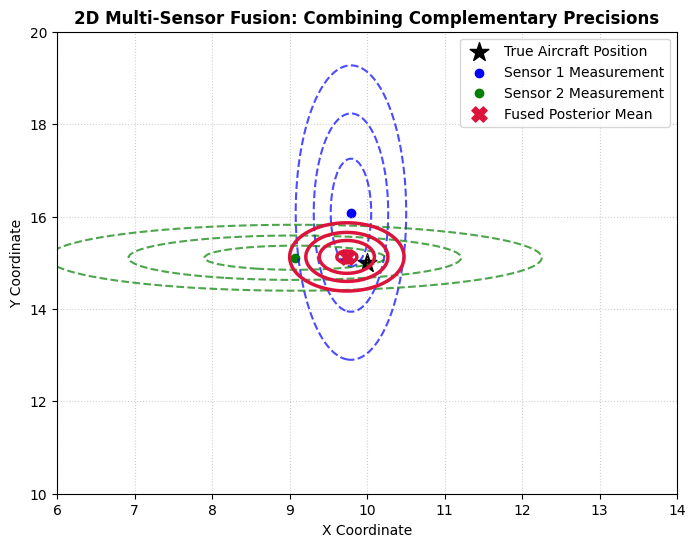

In [11]:
##Start code here...
#Simulation of 2D sensor fusion for aircraft position tracking
true_aircraft_pos = np.array([10.0, 15.0])

Sigma_s1 = np.array([[0.2, 0.0],
                     [0.0, 4.0]]) #high x-precision, and low y-precision
Sigma_s2 = np.array([[4.0, 0.0],
                     [0.0, 0.2]]) #low x-precision, and high-y precision

#Noisy observation from both sensors
y_s1 = np.random.multivariate_normal(true_aircraft_pos, Sigma_s1)
y_s2 = np.random.multivariate_normal(true_aircraft_pos, Sigma_s2)

#Prior over aircraft position(broad prior)
mu_z_air = np.array([0.0, 0.0])
Sigma_z_air = np.eye(2) * 100.0

#Bayesian Multi-Sensor Fusion Updates
Lambda_z_air = np.linalg.inv(Sigma_z_air)
Lambda_s1 = np.linalg.inv(Sigma_s1)
Lambda_s2 = np.linalg.inv(Sigma_s2)

Lambda_fused = Lambda_z_air + Lambda_s1 + Lambda_s2
Sigma_fused = np.linalg.inv(Lambda_fused)

mu_fused = Sigma_fused @ (Lambda_s1 @ y_s1 + Lambda_s2 @ y_s2 + Lambda_z_air @ mu_z_air)

print(f" True aircraft position : {true_aircraft_pos}")
print(f" Sensor 1 observation: {y_s1.round(2)}")
print(f" Sensor 2 observation: {y_s2.round(2)}")
print(f"   Fused Bayesian Estimate: {mu_fused.round(2)}")

#Visualizing the sensor fusion contours
x_grid = np.linspace(6, 14, 200)
y_grid = np.linspace(10, 20, 200)
X_g, Y_g = np.meshgrid(x_grid, y_grid)
pos_g = np.dstack((X_g, Y_g))

Z_s1 = stats.multivariate_normal(y_s1, Sigma_s1).pdf(pos_g)
Z_s2 = stats.multivariate_normal(y_s2, Sigma_s2).pdf(pos_g)
Z_fused = stats.multivariate_normal(mu_fused, Sigma_fused).pdf(pos_g)

#End code here...

plt.figure(figsize=(8, 6))
plt.contour(X_g, Y_g, Z_s1, levels=3, colors='blue', linestyles='--', alpha=0.7)
plt.contour(X_g, Y_g, Z_s2, levels=3, colors='green', linestyles='--', alpha=0.7)
plt.contour(X_g, Y_g, Z_fused, levels=4, colors='crimson', linewidths=2.5)

plt.scatter(true_aircraft_pos[0], true_aircraft_pos[1], color='black', marker='*', s=200, label='True Aircraft Position')
plt.scatter(y_s1[0], y_s1[1], color='blue', label='Sensor 1 Measurement')
plt.scatter(y_s2[0], y_s2[1], color='green', label='Sensor 2 Measurement')
plt.scatter(mu_fused[0], mu_fused[1], color='crimson', marker='X', s=120, label='Fused Posterior Mean')

plt.title('2D Multi-Sensor Fusion: Combining Complementary Precisions', fontweight='bold')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
